In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [14]:
dco_types = const.DCO_TYPES.copy()

In [ ]:
f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/stroopwafel_files/BHBH_Z_0.01052.h5

In [76]:
MET = 0.01052#0.00103

In [77]:
bpps = {dco_type: pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/stroopwafel_files/{dco_type}_Z_{MET}.h5", key="bpp") for dco_type in dco_types}

In [78]:
weights = {}
for dco_type in dco_types:
    with h5.File(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/stroopwafel_files/{dco_type}_Z_{MET}.h5", "r") as f:
        weights[dco_type] = f["stroopwafel"]["weights"][...][f["stroopwafel"]["is_hit"][...]]

In [79]:
kicks = {dco_type: pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/stroopwafel_files/{dco_type}_Z_{MET}.h5", key="kick_info") for dco_type in dco_types}

In [61]:
[["tphys", "mass_1", "mass_2", "kstar_1", "kstar_2", "sep", "ecc", "evol_type"]]

[['tphys',
  'mass_1',
  'mass_2',
  'kstar_1',
  'kstar_2',
  'sep',
  'ecc',
  'evol_type']]

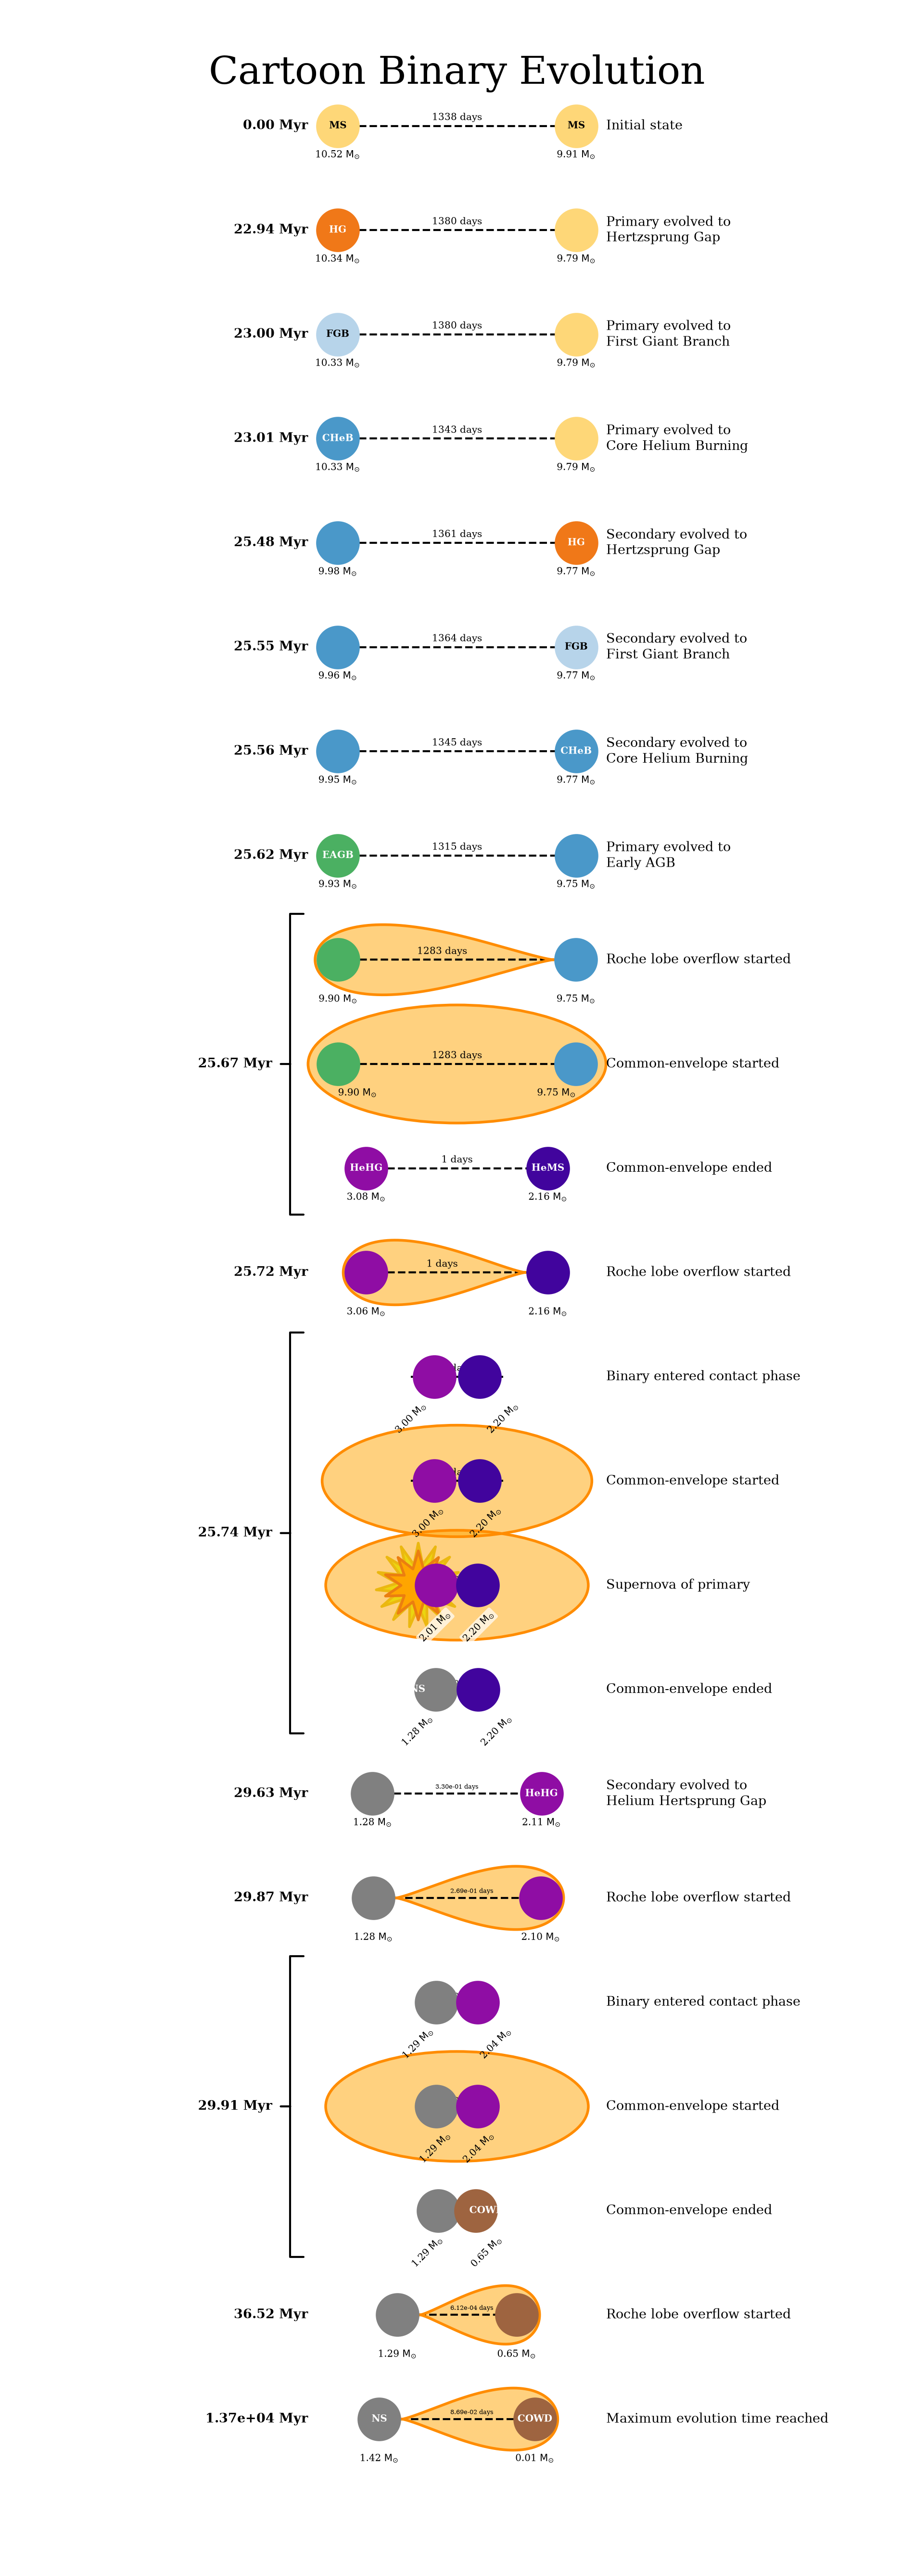

(<Figure size 1200x3450 with 1 Axes>, <Axes: >)

In [94]:
cogsworth.plot.plot_cartoon_evolution(bpps["NSWD"], bin_num=bpps[dco_type][mask].index[np.log10(bpps[dco_type][mask]["sep"]) < 0.5][3])#)bpps["NSWD"].index.unique()[2])

Index([  18758,   47052,   72473,   89650,   89993,  102228,  113750,  194344,
        203730,  218263,
       ...
       1999391, 1999412, 1999515, 1999525, 1999654, 1999673, 1999741, 1999789,
       1999803, 1999817],
      dtype='int64', length=7113)

130125 BHBH 130125
69759 BHNS 69759
16171 BHWD 16171
8873 NSNS 8873
20737 NSWD 20737


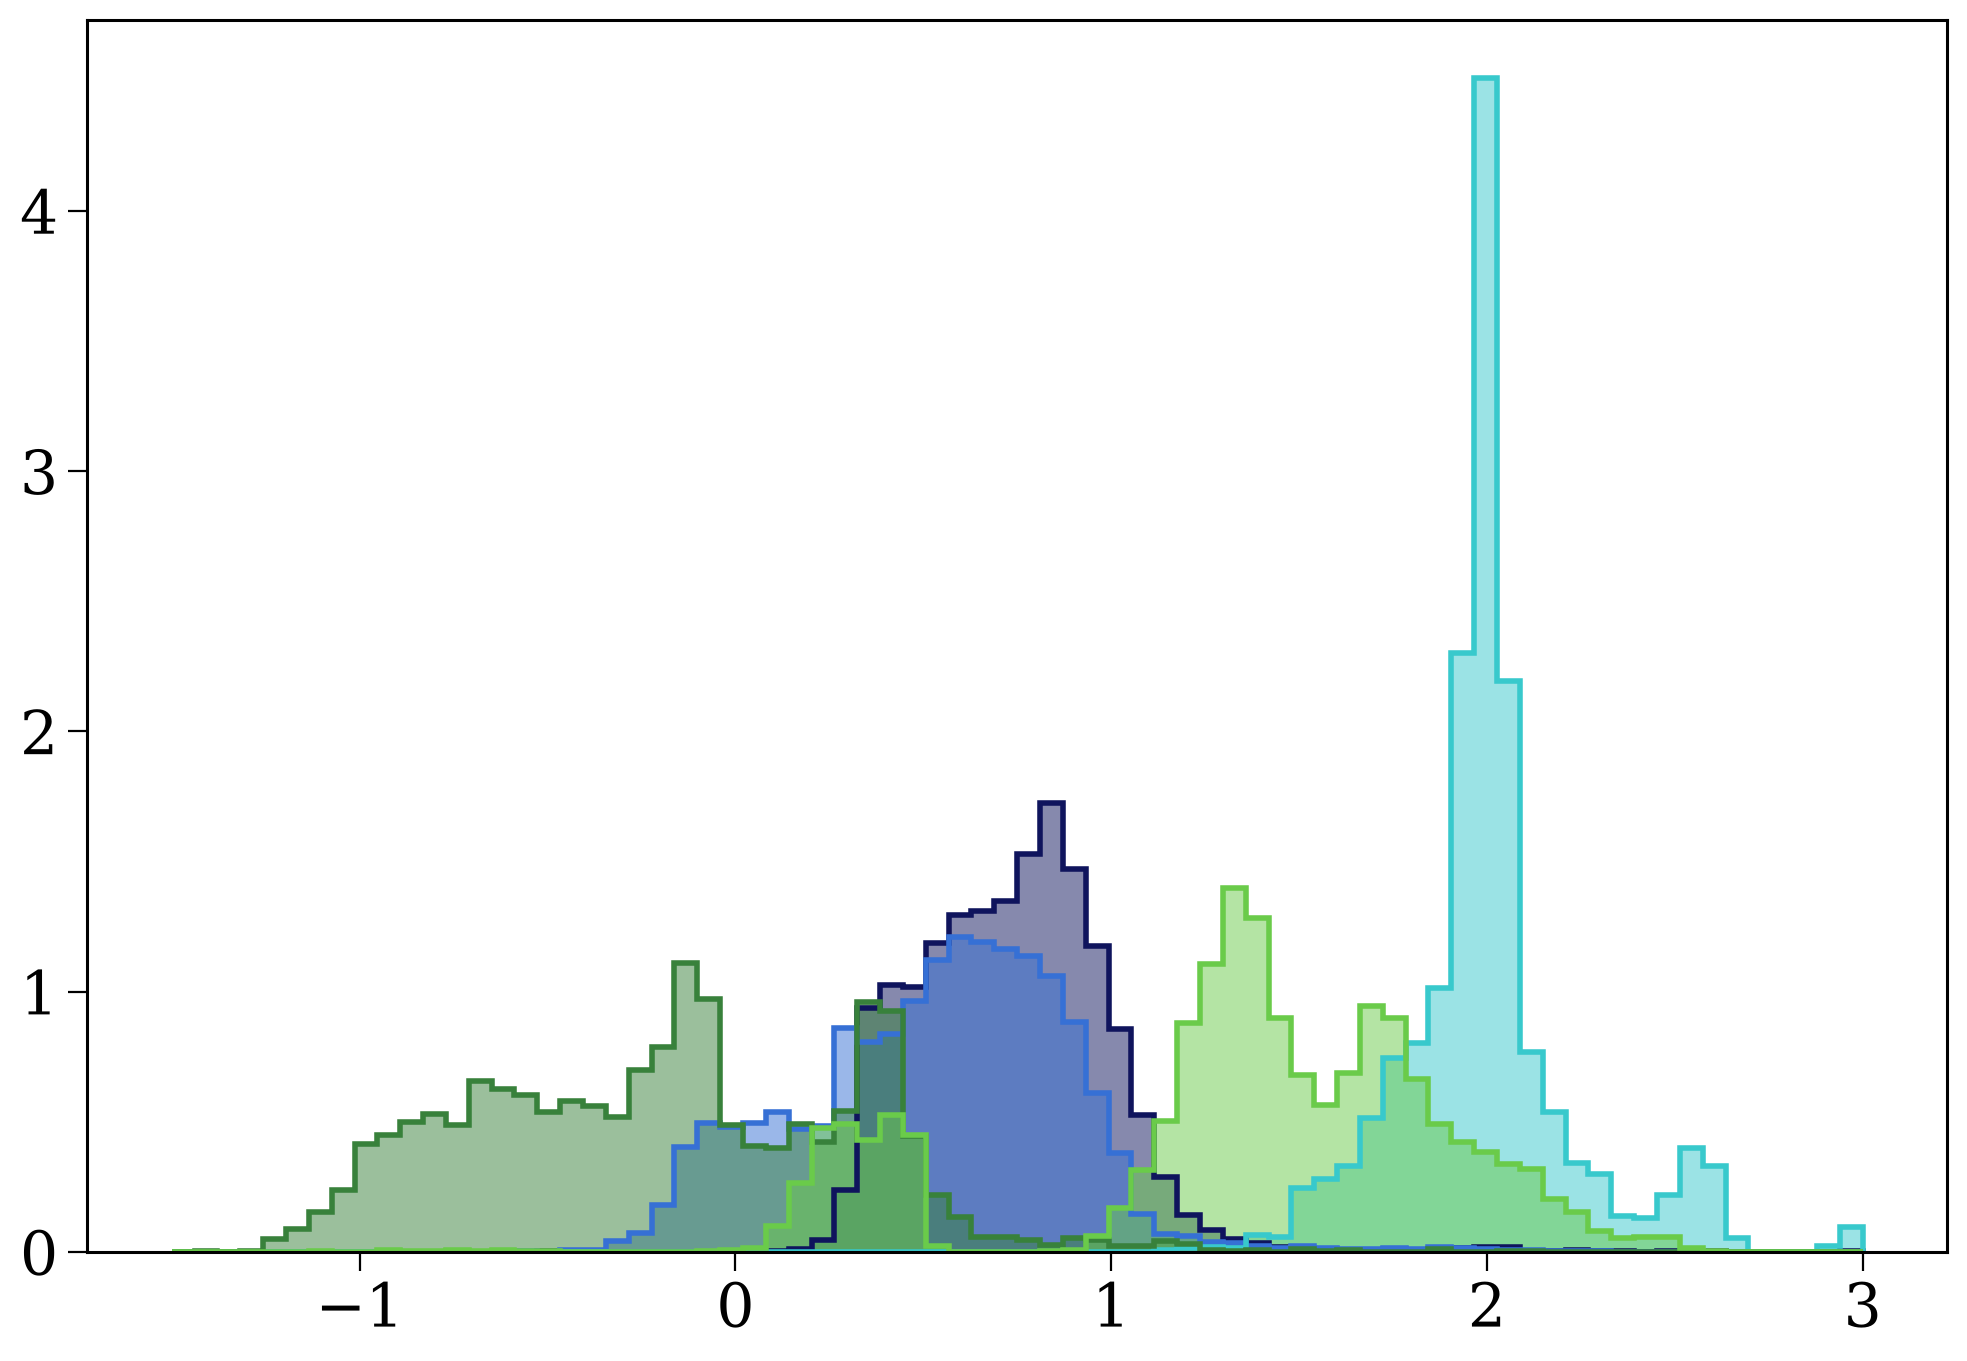

In [97]:
fig, ax = plt.subplots()

for dco_type in dco_types:
    mask = bpps[dco_type]["evol_type"].isin(([15, 16] if "WD" in dco_type else [16]))
    print(len(bpps[dco_type][mask]), dco_type, len(weights[dco_type]))

    weights_mask = np.isin(bpps[dco_type].index.unique(), bpps[dco_type][mask].index.unique())

    # print(bpps[dco_type][mask].index[np.log10(bpps[dco_type][mask]["sep"]) < 0.5], dco_type)

    plotting.nice_transparent_hist(ax=ax, data=np.log10(bpps[dco_type][mask]["sep"]), bins=np.linspace(-1.5, 3, 75),
                                   weights=weights[dco_type][weights_mask], alpha=0.5, colour=const.DCO_COLOURS[dco_type], label=dco_type, density=True);

349572 BHBH 349572
208644 BHNS 208644
113545 BHWD 113545
11276 NSNS 11276
28541 NSWD 28541


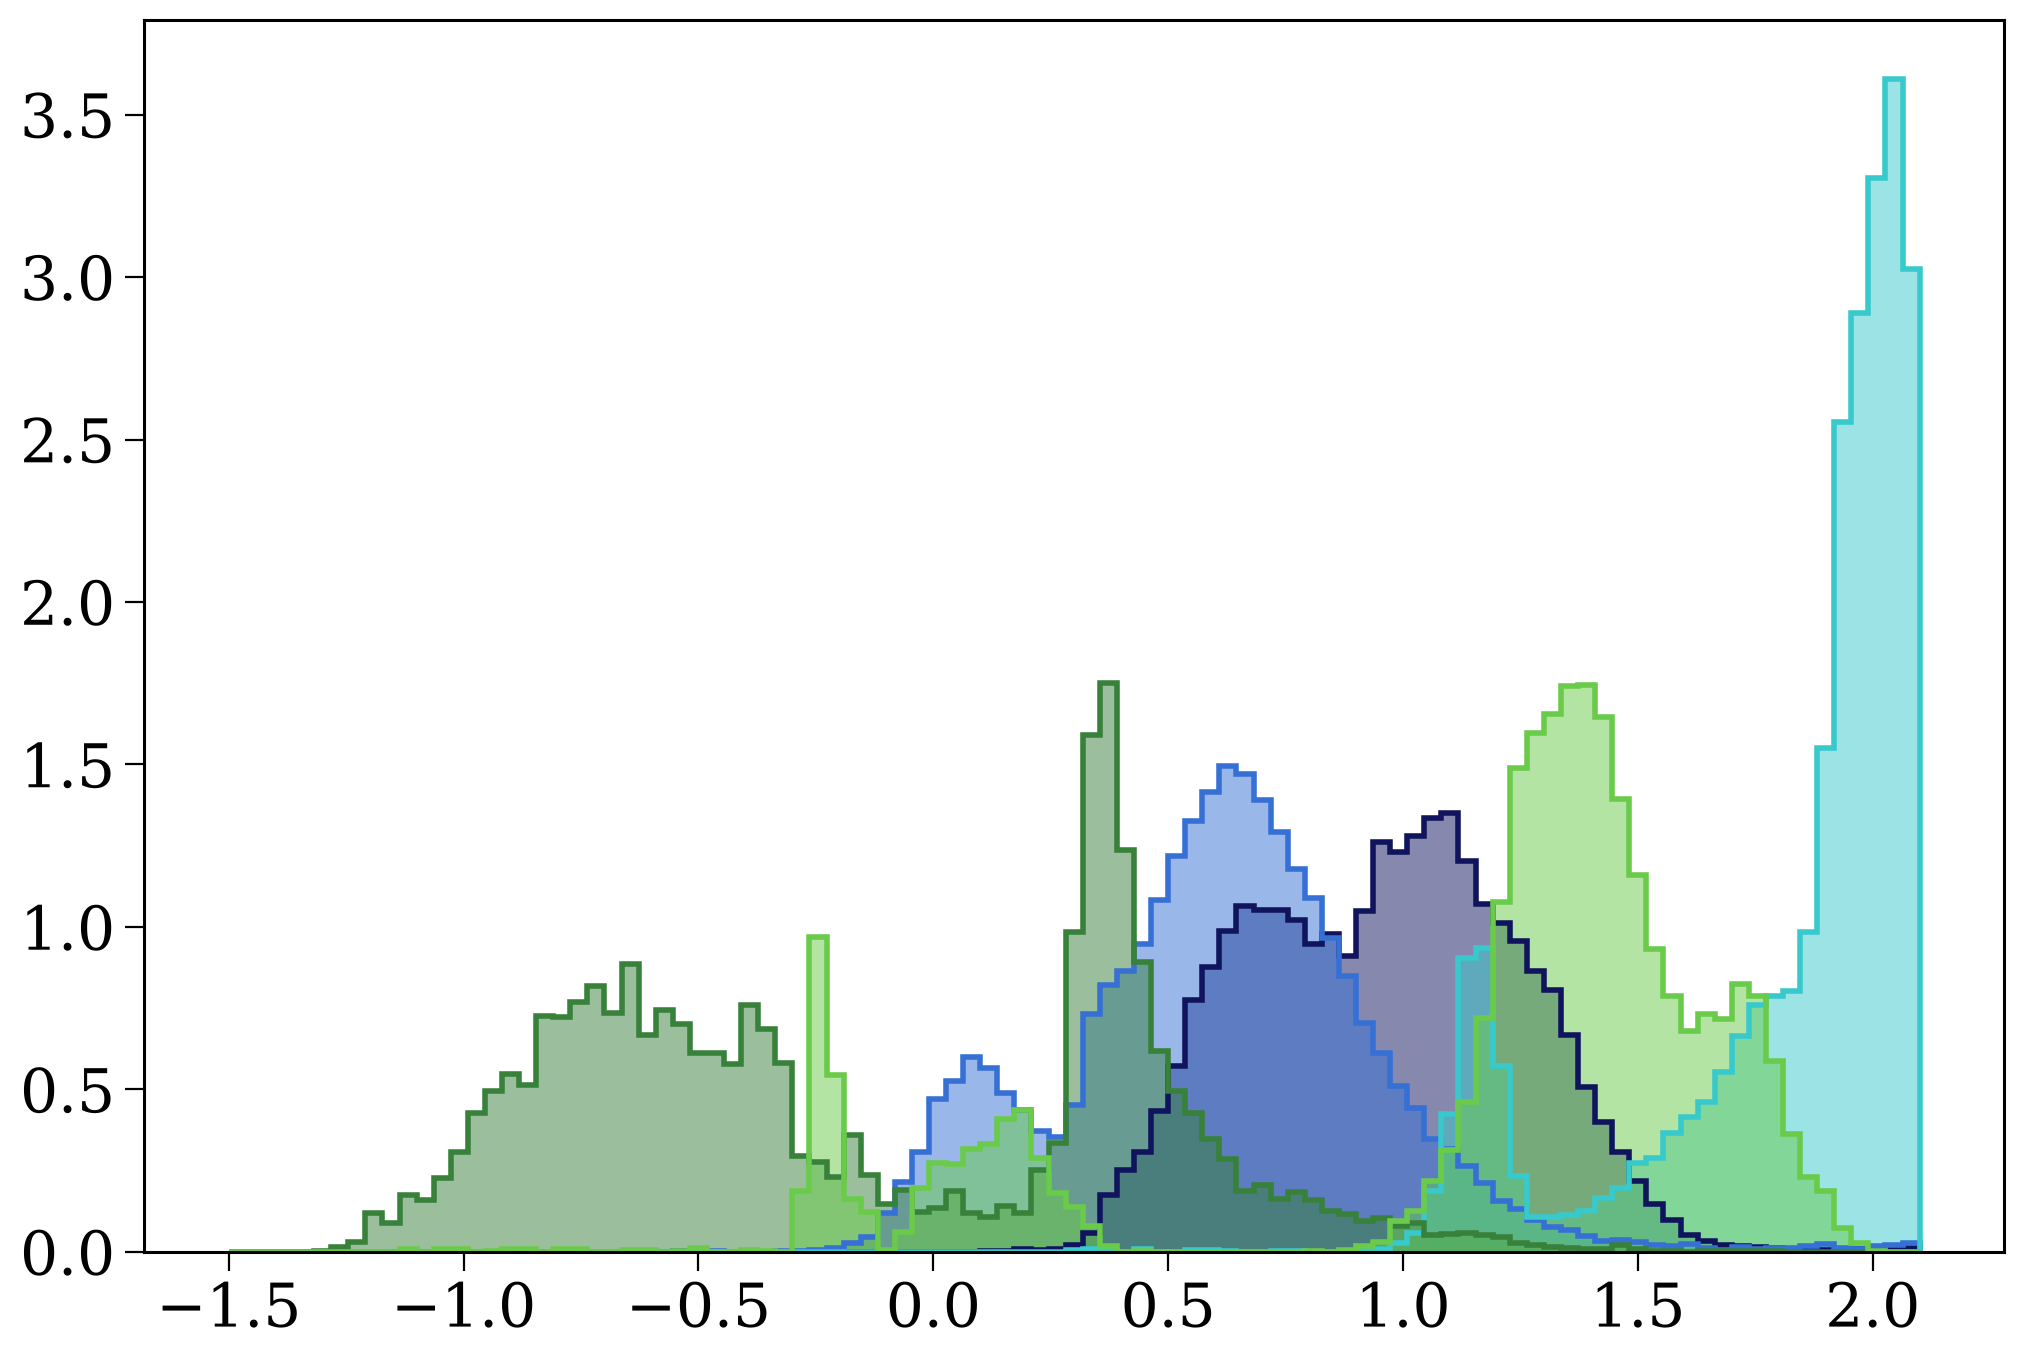

In [75]:
fig, ax = plt.subplots()

for dco_type in dco_types:
    mask = bpps[dco_type]["evol_type"].isin(([15, 16] if "WD" in dco_type else [16]))
    print(len(bpps[dco_type][mask]), dco_type, len(weights[dco_type]))

    weights_mask = np.isin(bpps[dco_type].index.unique(), bpps[dco_type][mask].index.unique())

    plotting.nice_transparent_hist(ax=ax, data=np.log10(bpps[dco_type][mask]["sep"]), bins=np.linspace(-1.5, 2.1, 100),
                                   weights=weights[dco_type][weights_mask], alpha=0.5, colour=const.DCO_COLOURS[dco_type], label=dco_type, density=True);

In [69]:
bpps["BHBH"].columns

Index(['tphys', 'mass_1', 'mass_2', 'kstar_1', 'kstar_2', 'sep', 'porb', 'ecc',
       'RRLO_1', 'RRLO_2', 'evol_type', 'aj_1', 'aj_2', 'tms_1', 'tms_2',
       'massc_he_layer_1', 'massc_he_layer_2', 'massc_co_layer_1',
       'massc_co_layer_2', 'rad_1', 'rad_2', 'mass0_1', 'mass0_2', 'lum_1',
       'lum_2', 'teff_1', 'teff_2', 'radc_1', 'radc_2', 'menv_1', 'menv_2',
       'renv_1', 'renv_2', 'omega_spin_1', 'omega_spin_2', 'B_1', 'B_2',
       'bacc_1', 'bacc_2', 'tacc_1', 'tacc_2', 'epoch_1', 'epoch_2',
       'bhspin_1', 'bhspin_2', 'bin_num'],
      dtype='str')

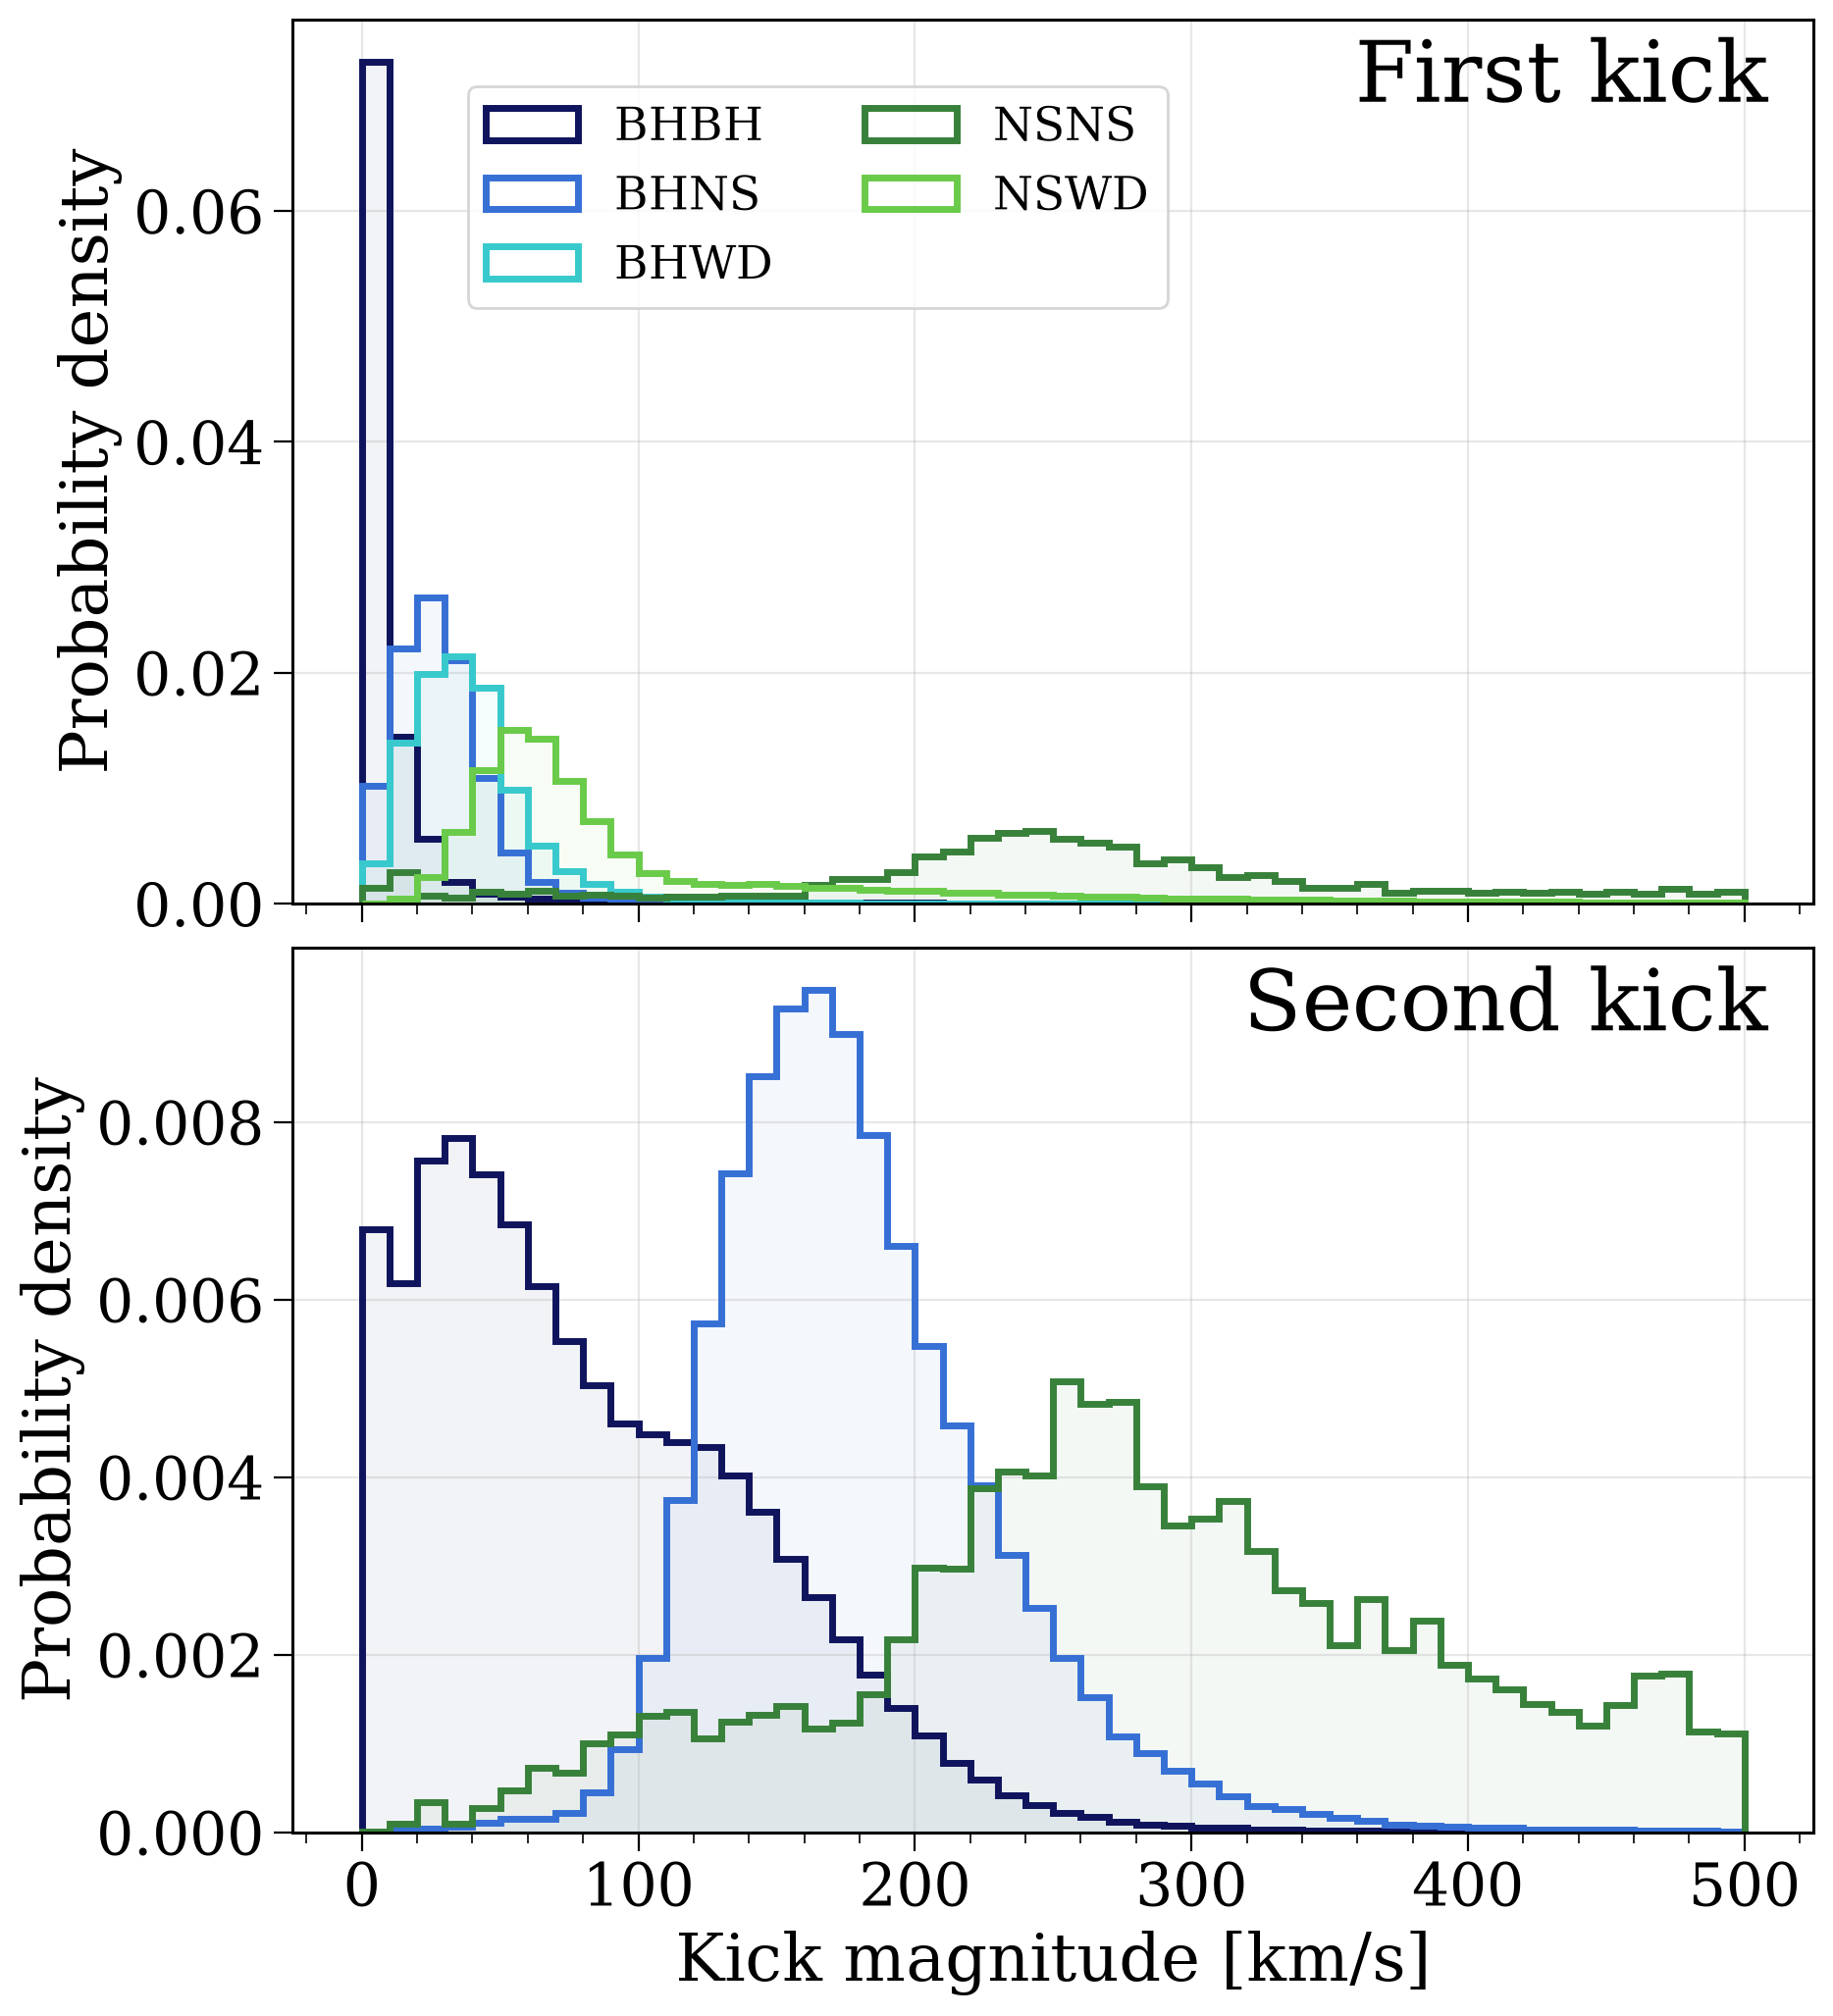

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

fig.subplots_adjust(hspace=0.05)

for dco_type in const.DCO_TYPES:
    kick_info = kicks[dco_type].copy()

    kick_info = kick_info[kick_info["star"] != 0]
    
    # groupby bin_num and separate into a row with the lowest tphys col and a row with the highest tphys col, then calculate the magnitude of the kick for each row
    first_kick = kick_info.sort_values(by="tphys").drop_duplicates(subset="bin_num", keep="first")
    second_kick = kick_info.sort_values(by="tphys").drop_duplicates(subset="bin_num", keep="last")

    first_kick_mag = np.linalg.norm(first_kick[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]].values, axis=1)
    second_kick_mag = np.linalg.norm(second_kick[["delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1"]].values, axis=1)

    bins = np.linspace(0, 500, 51)
    alpha = 0.05
    plotting.nice_transparent_hist(ax=axes[0], data=first_kick_mag, weights=weights[dco_type], bins=bins, label=f"{dco_type}", colour=const.DCO_COLOURS[dco_type], density=True, alpha=alpha, lw=2.5)

    if "WD" not in dco_type:
        plotting.nice_transparent_hist(ax=axes[1], data=second_kick_mag, weights=weights[dco_type], bins=bins, label=f"{dco_type}", colour=const.DCO_COLOURS[dco_type], density=True, alpha=alpha, lw=2.5)
    # axes[0].set_yscale("log")
    # axes[1].set_yscale("log")
axes[0].legend(loc="upper left", ncol=2, bbox_to_anchor=(0.1, 0.95))
# axes[0].set_ylim(top=0.04)

axes[0].annotate("First kick", xy=(0.97, 0.98), xycoords="axes fraction", ha='right', va="top", fontsize=1.3*fs, color="k",)
axes[1].annotate("Second kick", xy=(0.97, 0.98), xycoords="axes fraction", ha='right', va="top", fontsize=1.3*fs, color="k",)

for ax in axes:
    ax.set_ylabel("Probability density")
    ax.grid(alpha=0.3)
    ax.xaxis.set_minor_locator(plt.MultipleLocator(20))

axes[1].set_xlabel("Kick magnitude [km/s]")

# plt.savefig("../plots/kick_magnitudes_two_panels.pdf", bbox_inches="tight")
plt.show()

462903 BHBH 462903
259912 BHNS 259912
96649 BHWD 96649
9635 NSNS 9635
148704 NSWD 148704


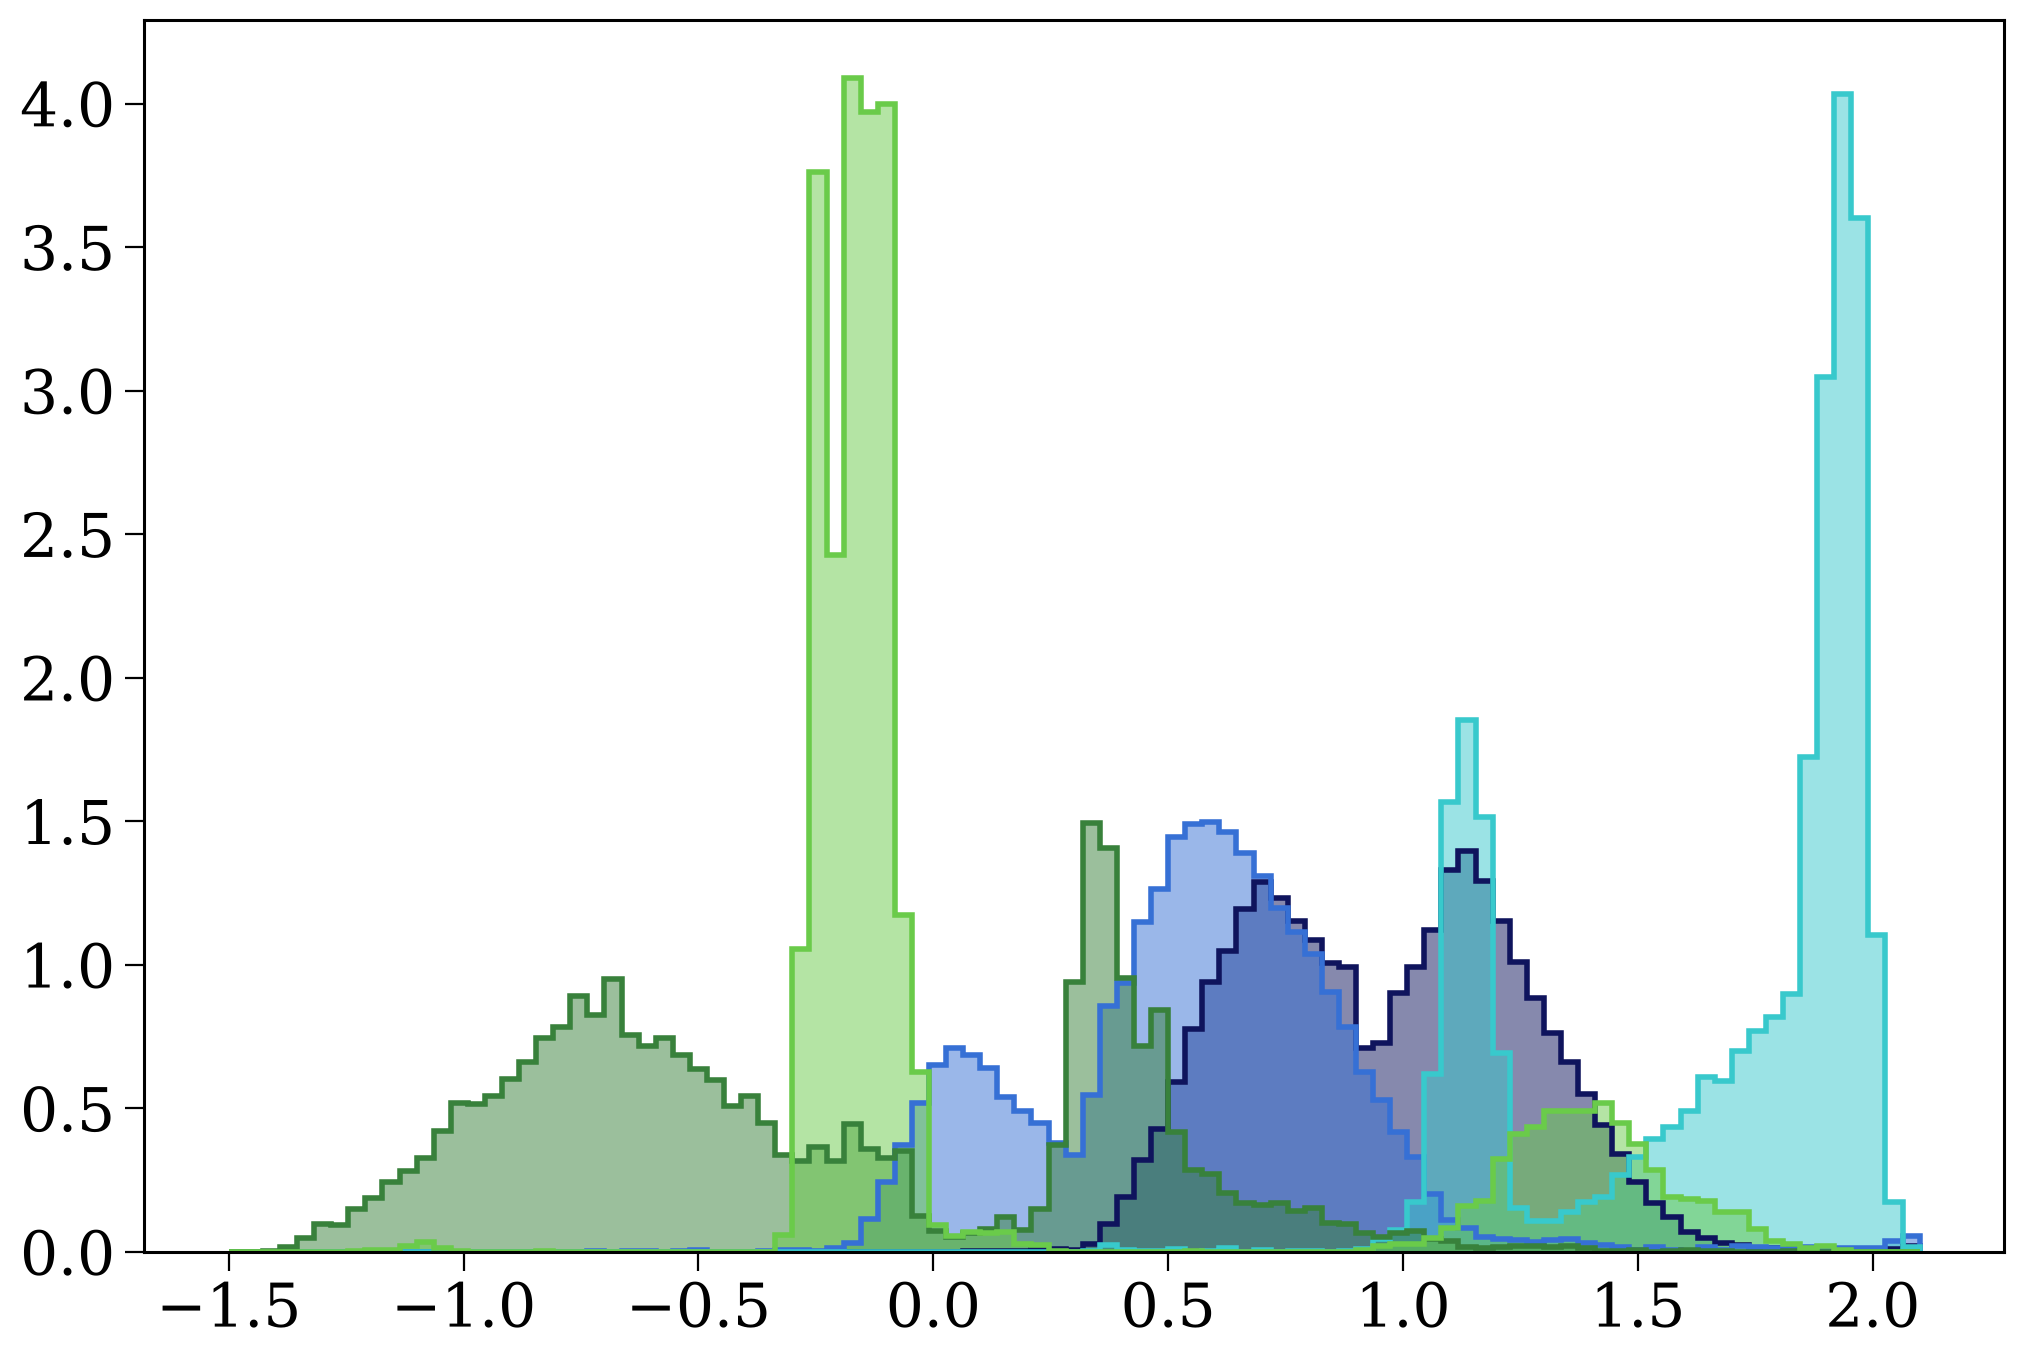

In [ ]:
fig, ax = plt.subplots()

for dco_type in dco_types:
    mask = bpps[dco_type]["evol_type"].isin(([15, 16] if "WD" in dco_type else [16]))
    print(len(bpps[dco_type][mask]), dco_type, len(weights[dco_type]))

    weights_mask = np.isin(bpps[dco_type].index.unique(), bpps[dco_type][mask].index.unique())

    plotting.nice_transparent_hist(ax=ax, data=np.log10(bpps[dco_type][mask]["sep"]), bins=np.linspace(-1.5, 2.1, 100),
                                   weights=weights[dco_type][weights_mask], alpha=0.5, colour=const.DCO_COLOURS[dco_type], label=dco_type, density=True);

In [98]:
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_in_band.h5") for dco_type in dco_types
}

In [99]:
for dco_type in dco_types:
    pop = pops[dco_type]
    print(dco_type)
    pop.final_pos, pop.final_vel

BHBH
BHNS
BHWD
NSNS
NSWD


In [100]:
detectable_pops = {}
for dco_type in dco_types:
    mask = (
        (pops[dco_type].bpp["snr_lisa_10yr_final_pos"] > 7)
        | (pops[dco_type].bpp["snr_lisa_10yr_initial_pos"] > 7)
        | (pops[dco_type].bpp["snr_decigo_10yr_final_pos"] > 7)
        | (pops[dco_type].bpp["snr_decigo_10yr_initial_pos"] > 7)
    )
    detectable_pops[dco_type] = pops[dco_type][mask]

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y